In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from utils import utils_ml 
from catboost import CatBoostClassifier
import glob
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.base import clone
from sklearn.multioutput import ClassifierChain
import joblib
import os

In [2]:
# Automatically find the matching file
input_files = glob.glob('training_features*.npy')
if not input_files:
    raise FileNotFoundError("No features_filtered*.npy file found in current directory")
input_path = input_files[0]

# Load memory-mapped array
print(f"Loading features from {input_path}")
X_arr = np.load(input_path, mmap_mode='r').astype(np.float32)

# Class mapping dictionary
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],  # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}


# File paths
file_prefix = "rawFeatures/P"
file_suffix = "_intensity.pkl"
num_files = 35

# Load labels
print("Loading labels...")
y_arr_classification = np.array([
    np.tile(i, 10000) 
    for i in np.arange(num_files)
]).flatten()

def convert_labels(old_labels, class_to_poles):
    """
    Convert class labels to pole representation.
    
    Parameters:
        old_labels (np.ndarray): Array of class labels.
        class_to_poles (dict): Mapping from class labels to pole representations.
        
    Returns:
        np.ndarray: A 2D array with pole representations.
    """
    # Initialize a new array with shape (length of old labels, 3)
    new_labels = np.zeros((len(old_labels), 3), dtype=int)
    
    # Populate the new label array based on the mapping
    for i, label in enumerate(old_labels):
        new_labels[i] = class_to_poles[label]
    
    return new_labels

indices = np.arange(350_000)
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, shuffle=True)

y_arr_r = convert_labels(y_arr_classification, class_to_poles) [test_idx]

class_to_poles_arr = np.array([class_to_poles[i] for i in range(num_files)])
y_bt = class_to_poles_arr[y_arr_classification][:, 0] [test_idx]
y_bb = class_to_poles_arr[y_arr_classification][:, 1] [test_idx]
y_tb = class_to_poles_arr[y_arr_classification][:, 2] [test_idx]

y_arr_classification = y_arr_classification[test_idx]
X_arr = X_arr[test_idx]

Loading features from training_features_128_T11T12NoBg.npy
Loading labels...


In [ ]:
class Ensemble(object):
    
    def __init__(self, esize=10, iterations=1000, seed=42):
        
        
        self.seed = seed
        self.esize=esize
        self.iterations=iterations
        self.ensemble = []
        for e in range(self.esize):
            model = CatBoostClassifier(iterations=self.iterations,
                           loss_function='MultiClass',
                           verbose=100,
                           bootstrap_type='No',
                           posterior_sampling=True,
                           random_seed=self.seed+e,
                           early_stopping_rounds=10)
            self.ensemble.append(model)
        
    def fit(self, X,y, eval_set = None):
        
        for m in self.ensemble:
            m.fit(X, y, use_best_model=True, early_stopping_rounds=10, eval_set=eval_set)
            print("best iter ", m.get_best_iteration())
            print("best score ", m.get_best_score())
            
    
    def predict(self,x):
        probs = []
        
        for m in self.ensemble:
            prob = m.predict_proba(x)
            probs.append(prob)
        probs = np.stack(probs)
        return probs
    
    def save(self, base_filepath):
        """Save the entire ensemble."""
        # Save ensemble metadata
        metadata = {
            'seed': self.seed,
            'esize': self.esize,
            'iterations': self.iterations,
        }
        joblib.dump(metadata, f"{base_filepath}_metadata.pkl")
        
        # Save each model in the ensemble
        os.makedirs(f"{base_filepath}_models", exist_ok=True)
        for idx, model in enumerate(self.ensemble):
            model.save_model(f"{base_filepath}_models/model_{idx}.cbm")
    
    def load(self, base_filepath):
        """Load the entire ensemble."""
        # Load metadata
        metadata = joblib.load(f"{base_filepath}_metadata.pkl")
        self.seed = metadata['seed']
        self.esize = metadata['esize']
        self.iterations = metadata['iterations']
       
        
        # Load each model
        self.ensemble = []
        for idx in range(self.esize):
            model = CatBoostClassifier(
                iterations=self.iterations,
                loss_function='MultiClass',
                verbose=100,
                bootstrap_type='No',
                posterior_sampling=True,
                random_seed=self.seed+idx,
                early_stopping_rounds=10
            )
            model.load_model(f"{base_filepath}_models/model_{idx}.cbm")
            self.ensemble.append(model)


def kl_divergence(probs1, probs2, epsilon=1e-10):
    return np.sum(probs1 * (np.log(probs1 + epsilon) - np.log(probs2 + epsilon)), axis=1)

def entropy_of_expected(probs, epsilon=1e-10):
    mean_probs = np.mean(probs, axis=0)
    log_probs = -np.log(mean_probs + epsilon)
    return np.sum(mean_probs * log_probs, axis=1)

def expected_entropy(probs, epsilon=1e-10):
    log_probs = -np.log(probs + epsilon)

    return np.mean(np.sum(probs * log_probs, axis=2), axis=0)

def mutual_information(probs, epsilon):
    eoe = entropy_of_expected(probs, epsilon)
    exe = expected_entropy(probs, epsilon)
    return eoe - exe

def ensemble_uncertainties(probs, epsilon=1e-10):
    mean_probs = np.mean(probs, axis=0)
    conf = np.max(mean_probs, axis=1)

    eoe = entropy_of_expected(probs, epsilon)
    exe = expected_entropy(probs, epsilon)
    mutual_info = eoe - exe


    uncertainty = {'confidence': conf,
                   'entropy_of_expected': eoe,        # total_uncertainty !
                   'expected_entropy': exe,           # data_uncertainty !
                   'mutual_information': mutual_info, # Knowledge Uncertainty!
                  }

    return uncertainty

class EnsembleWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, esize=10, iterations=1000, seed=100):
        self.esize = esize
        self.iterations = iterations
        self.seed = seed

        self.ensemble = Ensemble(
            esize=self.esize,
            iterations=self.iterations,
            seed=self.seed
        )

    def fit(self, X, y, eval_set=None):
        if eval_set is not None:
            X_val, y_val = eval_set
            eval_data = [(X_val, y_val)]
        else:
            eval_data = None
        self.ensemble.fit(X, y, eval_set=eval_data)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        probs = self.ensemble.predict(X)
        mean_probs = np.mean(probs, axis=0)
        return np.argmax(mean_probs, axis=1)

    def predict_proba(self, X):
        return np.mean(self.ensemble.predict(X), axis=0)

    def predict_with_uncertainty(self, X):
        probs = self.ensemble.predict(X)
        return ensemble_uncertainties(probs), probs
    
    def save_model(self, filepath):
        """Save the ensemble wrapper model."""
        # Save wrapper metadata
        wrapper_metadata = {
            'esize': self.esize,
            'iterations': self.iterations,
            'seed': self.seed,
            'classes_': getattr(self, 'classes_', None)
        }
        joblib.dump(wrapper_metadata, f"{filepath}_wrapper.pkl")
        
        # Save the ensemble
        self.ensemble.save(filepath)
    
    def load_model(self, filepath):
        """Load the ensemble wrapper model."""
        # Load wrapper metadata
        wrapper_metadata = joblib.load(f"{filepath}_wrapper.pkl")
        self.esize = wrapper_metadata['esize']
        self.iterations = wrapper_metadata['iterations']
        self.seed = wrapper_metadata['seed']
        if wrapper_metadata['classes_'] is not None:
            self.classes_ = wrapper_metadata['classes_']
        
        # Create and load the ensemble
        self.ensemble = Ensemble(
            esize=self.esize,
            iterations=self.iterations,
            seed=self.seed
        )
        self.ensemble.load(filepath)
        return self


class EvalClassifierChain(ClassifierChain):
    def fit(self, X, Y, eval_set=None, **fit_params):
        """Custom fit to support eval_set for each wrapped estimator."""
        X = np.asarray(X)
        Y = np.asarray(Y)

        self.order_ = self.order if self.order != 'random' else np.random.permutation(Y.shape[1])
        self.estimators_ = []

        for chain_idx, label_idx in enumerate(self.order_):
            y = Y[:, label_idx]
            if chain_idx > 0:
                X_extended = np.hstack((X, Y[:, self.order_[:chain_idx]]))
            else:
                X_extended = X

            estimator = clone(self.base_estimator)

            if eval_set is not None:
                X_val, Y_val = eval_set
                y_val = Y_val[:, label_idx]
                if chain_idx > 0:
                    X_val_extended = np.hstack((X_val, Y_val[:, self.order_[:chain_idx]]))
                else:
                    X_val_extended = X_val
                estimator.fit(X_extended, y, eval_set=(X_val_extended, y_val))
            else:
                estimator.fit(X_extended, y)

            self.estimators_.append(estimator)

        return self

    def save_chain(self, base_filepath):
        """Save the entire classifier chain."""
        # Save the chain structure using joblib
        chain_data = {
            'order_': self.order_,
            'order': self.order,
            'base_estimator': self.base_estimator
        }
        joblib.dump(chain_data, f"{base_filepath}_chain.pkl")
        
        # Save each individual estimator
        os.makedirs(f"{base_filepath}_chain_models", exist_ok=True)
        for idx, estimator in enumerate(self.estimators_):
            if hasattr(estimator, 'save_model'):
                estimator.save_model(f"{base_filepath}_chain_models/estimator_{idx}")
            else:
                joblib.dump(estimator, f"{base_filepath}_chain_models/estimator_{idx}.pkl")

    def load_chain(self, base_filepath, classes=None):
        """Load the entire classifier chain."""
        # Load chain structure
        chain_data = joblib.load(f"{base_filepath}_chain.pkl")
        self.order_ = chain_data['order_']
        self.order = chain_data['order']
        self.base_estimator = chain_data['base_estimator']
        
        # Load individual estimators
        self.estimators_ = []
        for idx in range(len(self.order_)):
            estimator = clone(self.base_estimator)
            
            if hasattr(estimator, 'load_model'):
                estimator.load_model(f"{base_filepath}_chain_models/estimator_{idx}")
                # Set classes if provided
                if classes is not None:
                    estimator.classes_ = classes
            else:
                pkl_path = f"{base_filepath}_chain_models/estimator_{idx}.pkl"
                if os.path.exists(pkl_path):
                    estimator = joblib.load(pkl_path)
            
            self.estimators_.append(estimator)
        
        return self

In [4]:
i = 1
base_model = EnsembleWrapper(esize=5, iterations=1000, seed=42)

unique_classes = np.array([0, 1, 2,])
new_chain = EvalClassifierChain(base_estimator=base_model, order=[0, 1, 2])
new_chain.load_chain(f"models/catboost_model_c3ru_fold{i}", classes=np.unique(y_arr_r))

# Verify loaded model works
y_pred = new_chain.predict(X_arr)
acc = accuracy_score(utils_ml.reconvert_labels(y_pred,class_to_poles),utils_ml.reconvert_labels(y_arr_r,class_to_poles))


In [5]:
# Get pole1 predictions + uncertainty
pole1_uncertainty, pole1_probs = new_chain.estimators_[0].predict_with_uncertainty(X_arr)
pole1_preds = np.argmax(np.mean(pole1_probs, axis=0), axis=1)
X2 = np.concatenate([X_arr, pole1_preds[:, None]], axis=1)

# Get pole2 predictions + uncertainty
pole2_uncertainty, pole2_probs = new_chain.estimators_[1].predict_with_uncertainty(X2)
pole2_preds = np.argmax(np.mean(pole2_probs, axis=0), axis=1)
X3 = np.concatenate([X2, pole2_preds[:, None]], axis=1)

# Get pole3 predictions + uncertainty
pole3_uncertainty, pole3_probs = new_chain.estimators_[2].predict_with_uncertainty(X3)

In [6]:
predictions = np.stack([np.argmax(np.mean(pole1_probs, axis=0), axis=1),
np.argmax(np.mean(pole2_probs, axis=0), axis=1),
np.argmax(np.mean(pole3_probs, axis=0), axis=1),],axis=1)

predictions_proba = np.stack([np.mean(pole1_probs, axis=0),
np.mean(pole2_probs, axis=0),
np.mean(pole3_probs, axis=0),],axis=1)

In [7]:
expected_entropy = np.stack([pole1_uncertainty["expected_entropy"],
                             pole2_uncertainty["expected_entropy"],
                             pole3_uncertainty["expected_entropy"]],axis=-1)

mutual_information = np.stack([pole1_uncertainty["mutual_information"],
                             pole2_uncertainty["mutual_information"],
                             pole3_uncertainty["mutual_information"]],axis=-1)

confidence = np.stack([pole1_uncertainty["confidence"],
                             pole2_uncertainty["confidence"],
                             pole3_uncertainty["confidence"]],axis=-1)


In [8]:
cumulative_entropy = np.cumsum(expected_entropy, axis=1)

In [9]:
accuracy_score(utils_ml.reconvert_labels(predictions,class_to_poles),utils_ml.reconvert_labels(y_arr_r,class_to_poles))

0.8284142857142858

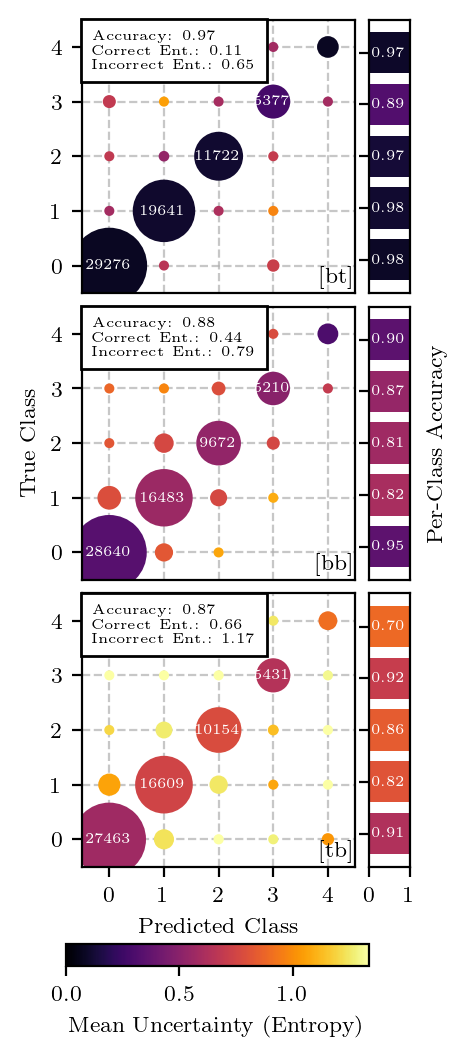

In [10]:
plt.rcParams.update({
    'font.size': 5,               # base font size
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 8
})


def create_plot(c_data):
    # Create a 3×1 grid of plots (one for each position), stacked vertically
    fig, axes = plt.subplots(3, 1, figsize=(3.5, 5.5), sharex=True)
    plt.subplots_adjust(hspace=0.05)  # Small vertical spacing

    positions = ['[bt]', '[bb]', '[tb]']
    n_classes = 5  # Classes 0-4

    cmap_uncertainty = plt.get_cmap("inferno")

    # Compute the max average class entropy across all positions
    max_avg_entropy = 0
    for pos in range(3):
        for cls in range(n_classes):
            mask = y_arr_r[:, pos] == cls
            if np.any(mask):
                avg_entropy = np.mean(c_data[mask, pos])
                max_avg_entropy = max(max_avg_entropy, avg_entropy)
    max_avg_entropy *=1.5 

    # Find global maximum entropy for consistent color scaling
    global_max_entropy = np.max(c_data) if c_data.size > 0 else 1.5
    global_max_count = 0  # For consistent circle sizing

    # First pass to determine maximum count for sizing
    for pos in range(3):
        for true_cls in range(n_classes):
            for pred_cls in range(n_classes):
                # Count samples where true_cls was predicted as pred_cls
                mask = (y_arr_r[:, pos] == true_cls) & (predictions[:, pos] == pred_cls)
                count = np.sum(mask)
                global_max_count = max(global_max_count, count)

    for pos in range(3):
        ax = axes[pos]
        
        # Create a confusion matrix filled with uncertainty data
        confusion_counts = np.zeros((n_classes, n_classes), dtype=int)
        mean_uncertainties = np.zeros((n_classes, n_classes))
        
        # Calculate how often each true-predicted class pair occurs and their mean uncertainty
        for true_cls in range(n_classes):
            for pred_cls in range(n_classes):
                # Find samples where true_cls was predicted as pred_cls
                mask = (y_arr_r[:, pos] == true_cls) & (predictions[:, pos] == pred_cls)
                confusion_counts[true_cls, pred_cls] = np.sum(mask)
                
                # Calculate mean uncertainty for this confusion
                if confusion_counts[true_cls, pred_cls] > 0:
                    mean_uncertainties[true_cls, pred_cls] = np.mean(c_data[mask, pos])
        
        # Calculate accuracy per class
        class_accuracies = np.zeros(n_classes)
        for cls in range(n_classes):
            if np.sum(y_arr_r[:, pos] == cls) > 0:
                class_accuracies[cls] = confusion_counts[cls, cls] / np.sum(confusion_counts[cls, :])
        
        # Calculate average entropy per class for coloring the accuracy bars
        class_avg_entropies = np.zeros(n_classes)
        for cls in range(n_classes):
            mask = y_arr_r[:, pos] == cls
            if np.sum(mask) > 0:
                class_avg_entropies[cls] = np.mean(c_data[mask, pos])
        
        # Create confusion matrix heatmap where:
        # - Circle size represents frequency of this confusion
        # - Color intensity represents mean uncertainty
        for true_cls in range(n_classes):
            for pred_cls in range(n_classes):
                if confusion_counts[true_cls, pred_cls] > 0:
                    # Calculate size based on count (normalized by max count)
                    size = 100 * (confusion_counts[true_cls, pred_cls] / global_max_count) ** 0.5
                    size = max(size, 10)  # Minimum size for visibility
                    
                    # Color based on mean uncertainty
                    color_intensity = mean_uncertainties[true_cls, pred_cls] / max_avg_entropy
                    
                    circle = plt.Circle((pred_cls, true_cls), radius=size/150, 
                                    color=cmap_uncertainty(color_intensity),
                                    alpha=1.0,zorder=2)
                    
                    ax.add_patch(circle)
                    
                    # Add text for count (only for significant counts)
                    if confusion_counts[true_cls, pred_cls] > global_max_count * 0.1:
                        ax.text(pred_cls, true_cls, f"{confusion_counts[true_cls, pred_cls]}", 
                                ha='center', va='center', 
                                color='white')# if color_intensity > 0.2 else 'white')
                    
        # Set grid and labels
        ax.set_aspect('equal')
        ax.set_xlim(-0.5, n_classes - 0.5)
        ax.set_ylim(-0.5, n_classes - 0.5)
        ax.set_xticks(range(n_classes))
        ax.set_yticks(range(n_classes))
        ax.set_xticklabels([f'{i}' for i in range(n_classes)])
        ax.set_yticklabels([f'{i}' for i in range(n_classes)])
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Add class accuracy as a horizontal bar on the right with colors based on entropy
        ax_acc = ax.inset_axes([1.05, 0, 0.15, 1])
        
        # Color bars based on average entropy per class - fixed height of 1
        bar_colors = [cmap_uncertainty(class_avg_entropies[cls] / max_avg_entropy) for cls in range(n_classes)]
        ax_acc.barh(range(n_classes), [1] * n_classes, color=bar_colors)
        
        ax_acc.set_yticks(range(n_classes))
        ax_acc.set_yticklabels([])
        ax_acc.set_xlim(0, 1)


        if pos == 1:
            ax_acc.set_ylabel('Per-Class Accuracy', fontsize=8, rotation=90, labelpad=-35)

        if pos == 2:
            pass
        else:
            ax_acc.set_xticklabels([]) 
            ax_acc.tick_params(axis='x', which='both', length=0)
        
        if pos < 2:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', which='both', length=0)

        # Change accuracy text color to white and center in fixed-width bars
        for i, acc in enumerate(class_accuracies):
            ax_acc.text(0.5, i, f"{acc:.2f}", ha='center', va='center', color='white')
        
        # Calculate statistics
        overall_acc = np.sum(np.diag(confusion_counts)) / np.sum(confusion_counts) if np.sum(confusion_counts) > 0 else 0
        avg_entropy = np.mean(c_data[:, pos])
        
        # Calculate average entropy for correct and incorrect predictions
        correct_mask = predictions[:, pos] == y_arr_r[:, pos]
        incorrect_mask = ~correct_mask
        entropy_correct = np.mean(c_data[correct_mask, pos]) if np.any(correct_mask) else 0
        entropy_incorrect = np.mean(c_data[incorrect_mask, pos]) if np.any(incorrect_mask) else 0
        
        # Add position label in bottom right
        ax.text(1.0, 0.015, positions[pos], transform=ax.transAxes,
                ha='right', va='bottom', fontsize=8,
                bbox=dict(facecolor='none', edgecolor='none', alpha=0.7))
        
        # Add statistics text in top left - revert to previous format
        stats_text = f"Accuracy: {overall_acc:.2f}\n" \
                    f"Correct Ent.: {entropy_correct:.2f}\n" \
                    f"Incorrect Ent.: {entropy_incorrect:.2f}"
        
        ax.text(0.036, 0.96, stats_text, transform=ax.transAxes,
                ha='left', va='top',  
                bbox=dict(facecolor='white', alpha=1.0))
        
        # Only add labels on specific subplots
        if pos == 1:  # Middle plot gets y-label
            ax.set_ylabel('True Class')
        
        if pos == 2:  # Bottom plot gets x-label
            ax.set_xlabel('Predicted Class')



    # Position colorbar below all axes
    cbar_ax = fig.add_axes([0.294, 0.02, 0.433, 0.02])  # [left, bottom, width, height]
    # sm = plt.cm.ScalarMappable(cmap=cmap_uncertainty)
    # sm.set_array([])
    from matplotlib import colors

    norm = colors.Normalize(vmin=0, vmax=max_avg_entropy)
    sm = plt.cm.ScalarMappable(cmap=cmap_uncertainty, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Mean Uncertainty (Entropy)')
    cbar.ax.tick_params(labelsize=8)

    # plt.savefig("confusion_uncertainty_analysis.pdf", dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

create_plot(cumulative_entropy)

In [11]:
correct_bt = predictions[:, 0] == y_arr_r[:, 0]
correct_bb = predictions[:, 1] == y_arr_r[:, 1]
correct_tb = predictions[:, 2] == y_arr_r[:, 2]

# Incorrect tb predictions only
tb_incorrect = ~correct_tb

# tb incorrect, but bb and bt were correct → model-specific failure
direct_tb_failures = tb_incorrect & correct_bt & correct_bb

# tb incorrect, and earlier errors exist
cascaded_tb_failures = tb_incorrect & ~(correct_bt & correct_bb)

mean_entropy_direct = np.mean(expected_entropy[direct_tb_failures, 2])
mean_entropy_cascaded = np.mean(expected_entropy[cascaded_tb_failures, 2])

print(f"TB errors from direct failures: {mean_entropy_direct:.2f}")
print(f"TB errors likely caused by cascaded errors: {mean_entropy_cascaded:.2f}")


TB errors from direct failures: 0.64
TB errors likely caused by cascaded errors: 0.34


In [12]:
# Get all samples where the true label of [tb] is 4
true_tb_4 = y_arr_r[:, 2] == 4

# But the prediction was wrong
pred_wrong_tb = predictions[:, 2] != 4

# And the model was overconfident (you can set a custom threshold, e.g., entropy < 0.5)
overconfident = expected_entropy[:, 2] < 0.5

# Combined mask: true label is 4, prediction is wrong, model is confident
mask = true_tb_4 & pred_wrong_tb & overconfident

# For these samples, extract relevant info
for i in np.where(mask)[0]:
    print(f"Sample {i}:")
    print(f"  True [bt], [bb], [tb]: {y_arr_r[i]}")
    print(f"  Pred [bt], [bb], [tb]: {predictions[i]}")
    print(f"  Entropies [bt], [bb], [tb]: {expected_entropy[i]}")
    print(f"  Confidence [bt], [bb], [tb]: {confidence[i]}")
    
    bt_correct = predictions[i, 0] == y_arr_r[i, 0]
    bb_correct = predictions[i, 1] == y_arr_r[i, 1]
    
    if not bt_correct or not bb_correct:
        print("  ❗ Error(s) in earlier stages may have propagated.")
    else:
        print("  ✅ Earlier stages correct — final model likely at fault.")
    print("-" * 50)


Sample 6:
  True [bt], [bb], [tb]: [0 0 4]
  Pred [bt], [bb], [tb]: [3 1 0]
  Entropies [bt], [bb], [tb]: [0.75567241 0.04792225 0.04060095]
  Confidence [bt], [bb], [tb]: [0.52211659 0.99199394 0.99322157]
  ❗ Error(s) in earlier stages may have propagated.
--------------------------------------------------
Sample 135:
  True [bt], [bb], [tb]: [0 0 4]
  Pred [bt], [bb], [tb]: [3 1 0]
  Entropies [bt], [bb], [tb]: [0.70389546 0.02872999 0.01566886]
  Confidence [bt], [bb], [tb]: [0.50376024 0.99560816 0.99779503]
  ❗ Error(s) in earlier stages may have propagated.
--------------------------------------------------
Sample 289:
  True [bt], [bb], [tb]: [0 0 4]
  Pred [bt], [bb], [tb]: [3 1 0]
  Entropies [bt], [bb], [tb]: [0.90701113 0.17735802 0.00934241]
  Confidence [bt], [bb], [tb]: [0.54977262 0.96246307 0.99875947]
  ❗ Error(s) in earlier stages may have propagated.
--------------------------------------------------
Sample 578:
  True [bt], [bb], [tb]: [0 0 4]
  Pred [bt], [bb], [t

In [13]:
# Gather all entropies and confidences from selected failing samples
entropies_all = []
confidences_all = []

for i in np.where(mask)[0]:
    entropies_all.append(expected_entropy[i])
    confidences_all.append(confidence[i])  # Make sure you have confidence[:, pos] available

entropies_all = np.array(entropies_all)
confidences_all = np.array(confidences_all)

# Compute mean ± std across all three positions
mean_entropy = np.mean(entropies_all, axis=0)
std_entropy = np.std(entropies_all, axis=0)

mean_confidence = np.mean(confidences_all, axis=0)
std_confidence = np.std(confidences_all, axis=0)

# Print in ± notation
for i, label in enumerate(['bt', 'bb', 'tb']):
    print(f"Entropy [{label}]: {mean_entropy[i]:.2f} ± {std_entropy[i]:.2f}")
    print(f"Confidence [{label}]: {mean_confidence[i]:.2f} ± {std_confidence[i]:.2f}")


Entropy [bt]: 0.70 ± 0.10
Confidence [bt]: 0.57 ± 0.09
Entropy [bb]: 0.08 ± 0.15
Confidence [bb]: 0.97 ± 0.09
Entropy [tb]: 0.02 ± 0.05
Confidence [tb]: 1.00 ± 0.02
